# 🧬 AMR-Predictor-ML: Predicting Meropenem Resistance in *Klebsiella pneumoniae*
## Phase 5: Hyperparameter Tuning & Cost-Sensitive Learning

### 📋 Phase Overview
While feature selection improved our baseline Recall, univariate selection caused a slight drop in ROC-AUC. In this phase, we will implement **Cost-Sensitive Learning** using XGBoost's `scale_pos_weight` parameter on both the full feature dataset and the reduced dataset to heavily penalize False Negatives, forcing the model to maximize its Sensitivity (Recall) for the Resistant class.

### 🎯 Notebook Objectives
1. Train a cost-sensitive XGBoost model utilizing class imbalance weights ($1764 / 1072 \approx 1.65$).
2. Compare the optimization impact on the Full Dataset ($4,096$ features) vs. Selected Dataset ($500$ features).
3. Maximize the Resistant Recall toward clinical acceptability.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 1. Load the selected dataset
dataset_path = "../data/processed/kmers_6_selected_500.csv"
df = pd.read_csv(dataset_path)

# 2. Split
metadata_cols = ['Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'AMR_Label']
y = df['AMR_Label'].values
X = df.drop(columns=metadata_cols).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Calculate the exact scale_pos_weight
# Ratio of negative class (0) to positive class (1)
num_susceptible = np.sum(y_train == 0)
num_resistant = np.sum(y_train == 1)
calculated_weight = num_susceptible / num_resistant

print(f"⚖️ Calculated Class Weight (scale_pos_weight): {calculated_weight:.2f}")

# 4. Train Optimized XGBoost
print("🚀 Training Cost-Sensitive XGBoost Model...")
optimized_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=calculated_weight, # <--- The Magic Parameter!
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

optimized_xgb.fit(X_train, y_train)
print("✅ Training complete!")

# 5. Evaluate
y_pred = optimized_xgb.predict(X_test)
y_prob = optimized_xgb.predict_proba(X_test)[:, 1]

print("\n📊 === Optimized XGBoost Evaluation Summary ===")
print(f"🎯 Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"📈 ROC-AUC  : {roc_auc_score(y_test, y_prob)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Susceptible (0)", "Resistant (1)"]))

⚖️ Calculated Class Weight (scale_pos_weight): 1.65
🚀 Training Cost-Sensitive XGBoost Model...
✅ Training complete!

📊 === Optimized XGBoost Evaluation Summary ===
🎯 Accuracy : 65.85%
📈 ROC-AUC  : 69.88%
                 precision    recall  f1-score   support

Susceptible (0)       0.73      0.72      0.72       353
  Resistant (1)       0.55      0.56      0.55       215

       accuracy                           0.66       568
      macro avg       0.64      0.64      0.64       568
   weighted avg       0.66      0.66      0.66       568



In [3]:
# 1. Load the FULL golden dataset (The 4,096 features version)
full_dataset_path = "../data/processed/kmers_6_dataset.csv"
print("⏳ Loading FULL Golden Dataset (4,096 features)...")
df_full = pd.read_csv(full_dataset_path)

# 2. Separate Features and Target
metadata_cols = ['Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'AMR_Label']
y_full = df_full['AMR_Label'].values
X_full = df_full.drop(columns=metadata_cols).values

# 3. Stratified Train/Test Split (80/20) - exact same seed 42
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42, stratify=y_full
)

# 4. Initialize XGBoost with the FULL features and Class Weights
print("🚀 Training Cost-Sensitive XGBoost on all 4,096 K-mers...")
final_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=1.65, # Penalize misclassifying resistant strains
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

final_xgb.fit(X_train_f, y_train_f)
print("✅ Training complete!")

# 5. Evaluate the results
y_pred_f = final_xgb.predict(X_test_f)
y_prob_f = final_xgb.predict_proba(X_test_f)[:, 1]

print("\n📊 === Full Dataset Cost-Sensitive XGBoost Results ===")
print(f"🎯 Accuracy : {accuracy_score(y_test_f, y_pred_f)*100:.2f}%")
print(f"📈 ROC-AUC  : {roc_auc_score(y_test_f, y_prob_f)*100:.2f}%")
print(classification_report(y_test_f, y_pred_f, target_names=["Susceptible (0)", "Resistant (1)"]))

⏳ Loading FULL Golden Dataset (4,096 features)...
🚀 Training Cost-Sensitive XGBoost on all 4,096 K-mers...
✅ Training complete!

📊 === Full Dataset Cost-Sensitive XGBoost Results ===
🎯 Accuracy : 70.25%
📈 ROC-AUC  : 75.31%
                 precision    recall  f1-score   support

Susceptible (0)       0.76      0.77      0.76       353
  Resistant (1)       0.61      0.59      0.60       215

       accuracy                           0.70       568
      macro avg       0.68      0.68      0.68       568
   weighted avg       0.70      0.70      0.70       568



### 📊 Visualizing Model Performance: Confusion Matrix & ROC Curve

To fully understand the clinical impact and trade-offs of our **Optimized Full-Dataset XGBoost model**, we visualize its performance using two essential diagnostic plots:

1. **Confusion Matrix**: This will show us the exact count of:
   * **True Negatives (TN)**: Correctly identified Susceptible strains.
   * **True Positives (TP)**: Correctly identified Resistant strains (our main focus).
   * **False Negatives (FN)**: Strains that are actually Resistant but predicted as Susceptible (the clinically dangerous errors).
   * **False Positives (FP)**: Strains that are actually Susceptible but predicted as Resistant.

2. **ROC Curve (Receiver Operating Characteristic)**: This curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity) across all possible classification thresholds. The **AUC (Area Under the Curve) of 75.31%** quantifies the overall ability of our 4,096 K-mer features to discriminate between the two phenotypes.

/tmp/ipykernel_2721/113588398.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721/113588398.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/azureuser/miniconda3/envs/amr_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/azureuser/miniconda3/envs/amr_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


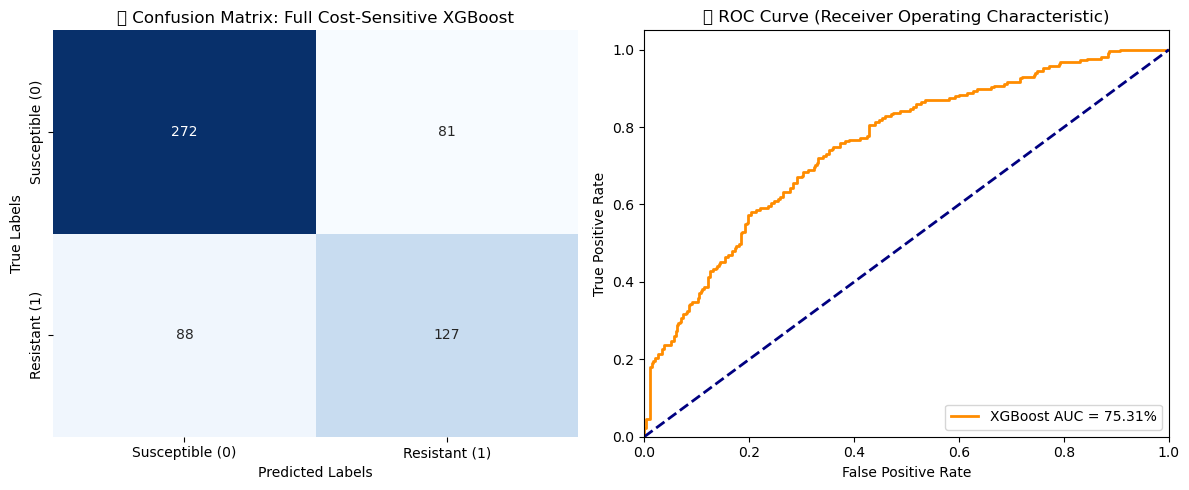

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

# 1. Generate Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_f)

plt.figure(figsize=(12, 5))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Susceptible (0)", "Resistant (1)"],
            yticklabels=["Susceptible (0)", "Resistant (1)"])
plt.title("📊 Confusion Matrix: Full Cost-Sensitive XGBoost")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

# 2. Generate ROC Curve
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost AUC = {roc_auc_score(y_test_f, y_prob_f)*100:.2f}%')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("📈 ROC Curve (Receiver Operating Characteristic)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()